This notebook was translated into English using AI and may contain minor errors.

# Part 1

First, we need to import all the libraries we use. We use `pydataset` to load the data, `pandas` and `sklearn` for analysis, and `seaborn` and `matplotlib` for graphical representation.

In [1]:
from pydataset import data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In the variable `frame`, we store the `pydataset` data about airline companies over a 15-year period (1970–1984). The `data()` function returns the `DataFrame` type, so there is no need to convert it.

In [2]:
frame = data("Airline")

Since the table includes data about several companies, we select only one because it would be meaningless to compare data between different companies. We will compare the data in the columns `cost` (the company's costs in a year) and `pf` (fuel costs in a year). The cost data are in thousands of dollars (/1000$). We remove the other columns.

In [3]:
frame = frame[frame["airline"] == 1]
frame = frame[["cost", "pf"]]

In [4]:
costMean = frame["cost"].mean()
pfMean = frame["pf"].mean()

In [5]:
costMean

2639003.3333333335

In [6]:
pfMean

462320.2

In [7]:
pfMean/costMean

0.1751874255558601

We see that average spending on fuel accounts for a significant share of average spending overall.

Now we calculate the standard deviations of these values over that range. Since we have complete information available for the range in question, we are working with entire populations, so we need to call the function with `ddof = 0`.

In [8]:
costStd = frame["cost"].std(ddof = 0)
pfStd = frame["pf"].std(ddof = 0)

In [9]:
costStd

1199381.7672376975

In [10]:
pfStd

331241.1615169427

We see that the standard deviation of the ``pf`` column (i.e., the one showing fuel costs) is quite large, which suggests that spending on fuel varied over a wide range during that period. Indeed, around 1980, the price of fuel rose considerably, and so did spending on it. The value of the variable ``costStd`` is also quite large; therefore, the total cost also varied considerably, which suggests a relationship between the two variables.

We calculate the medians similarly to the arithmetic means.

In [11]:
costMedian = frame["cost"].median()
pfMedian = frame["pf"].median()

In [12]:
costMedian

2314760.0

In [13]:
pfMedian

316411.0

From this, one could perhaps comment on the relatively large difference between the values of the variables ``pfMean`` and ``pfMedian``, which is expected since the standard deviation is also large.

In [14]:
(pfMean - pfMedian)/pfMean

0.3156020437783164

We can obtain the quartiles using the `quantile()` attribute. We need to specify that we want quartiles, i.e., enter the values `[0.25, 0.5, 0.75]` as the argument. We also convert the result to a `DataFrame` for easier display and possible future work.

In [15]:
costQuartiles = pd.DataFrame(frame["cost"].quantile([0.25, 0.5, 0.75]))
pfQuartiles = pd.DataFrame(frame["pf"].quantile([0.25, 0.5, 0.75]))

In [16]:
costQuartiles

,cost
0.25,1594130.0
0.50,2314760.0
0.75,3827750.0


In [17]:
pfQuartiles

,pf
0.25,159290.0
0.50,316411.0
0.75,841491.5


The quartiles also reveal a large difference between the smallest and largest values in the ``pf`` and ``cost`` columns, i.e., the values vary over a wide range.

Now we calculate the covariance and correlation. For similar reasons as before, we need to include the argument `ddof = 0` for the covariance. Also, since the returned values are tables (which also show the covariance/correlation of the variables `cost, pf` with themselves, which we do not need), we need to select the value from the cell we want using `iat`.

In [18]:
dataCov = frame.cov(ddof = 0).iat[0, 1]
dataCorr = frame.corr().iat[0, 1]

In [19]:
dataCov

381596215293.3334

In [20]:
dataCorr

0.9605109435241395

We see that the correlation is very close to $1$, so we expect the variables to be linearly related, and it makes sense to perform linear regression. Both values are also positive, so we know that higher values of the variable `pf` will correspond to higher values of the variable `cost`, and vice versa.

Now we generate the regression line and scatter plot using the `seaborn` and `matplotlib` libraries. We set the total cost as the dependent variable to visualize how spending on fuel (and thus its price) affects the total cost of an individual airline company. We also label the axes and the overall plot. We will color the line red for clarity.

Text(0.5, 1.0, 'Relationship between total cost and fuel costs')

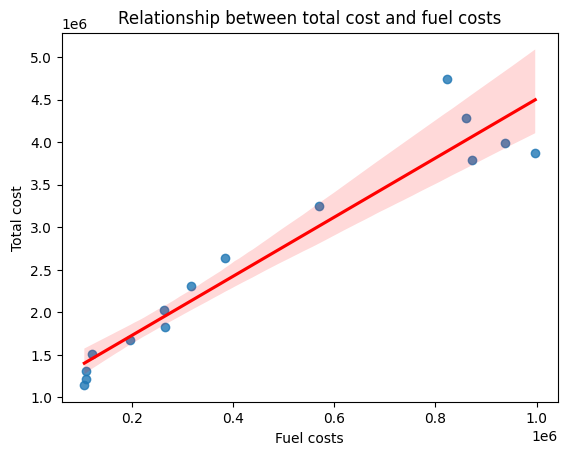

In [21]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"})
plt.xlabel("Fuel costs")
plt.ylabel("Total cost")
plt.title("Relationship between total cost and fuel costs")

We see a very high positive correlation between the total cost and fuel costs. We see that, at higher values of the parameter `pf`, the approximation of the data by a line is somewhat worse than at lower values, probably because they correspond to the period of fuel price instability around 1980, which may have disrupted the relationship between the variables. Nevertheless, we see that the values are closely related, so the total cost also rose considerably along with fuel costs.

If we want to display only the regression line or only the scatter plot, we can add ``scatter = False`` or ``fit_reg = False`` as arguments, respectively.

Text(0.5, 1.0, 'Relationship between total cost and fuel costs')

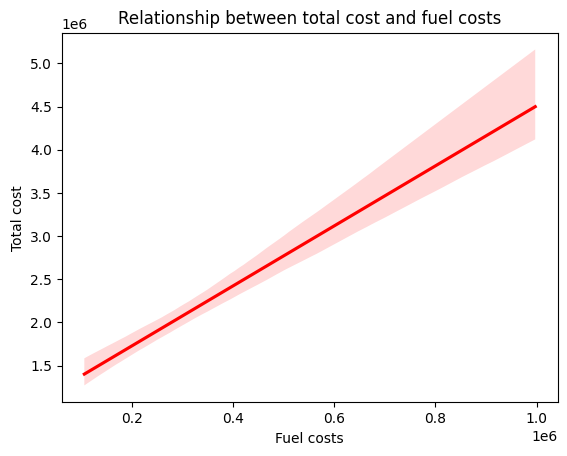

In [22]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"}, scatter = False)
plt.xlabel("Fuel costs")
plt.ylabel("Total cost")
plt.title("Relationship between total cost and fuel costs")

Text(0.5, 1.0, 'Relationship between total cost and fuel costs')

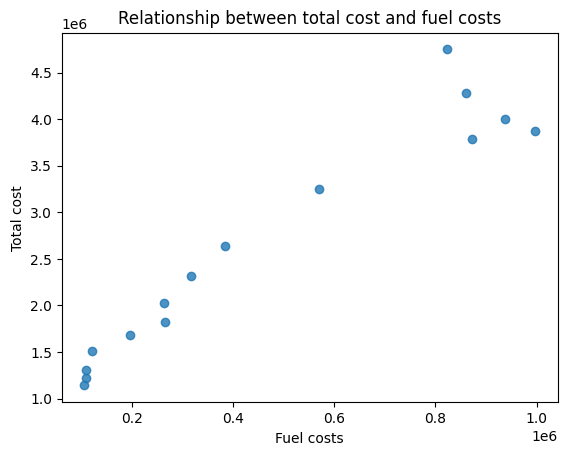

In [23]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"}, fit_reg = False)
plt.xlabel("Fuel costs")
plt.ylabel("Total cost")
plt.title("Relationship between total cost and fuel costs")

# Part 2

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import sklearn.datasets
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pydataset import data
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans

We will analyze a dataset of the total number of international airline passengers per month, expressed as $\log_{10}(\frac{x}{1000})$ by year, where $x$ is the total number of passengers that month. We load the data using the `pydataset` library.

In [2]:
frame = data("AirPassengers")
frame

,time,AirPassengers
1,1949.000000,112
2,1949.083333,118
3,1949.166667,132
4,1949.250000,129
5,1949.333333,121
6,1949.416667,135
7,1949.500000,148
8,1949.583333,148
9,1949.666667,136
10,1949.750000,119


Both variables are continuous, so we will examine the plot and perform regression. We therefore split the data into training and test sets.

In [3]:
x_train, x_test, y_train, y_test = train_test_split(frame[["time"]], frame["AirPassengers"], test_size=0.2, random_state=42)

Text(0, 0.5, 'Number of passengers')

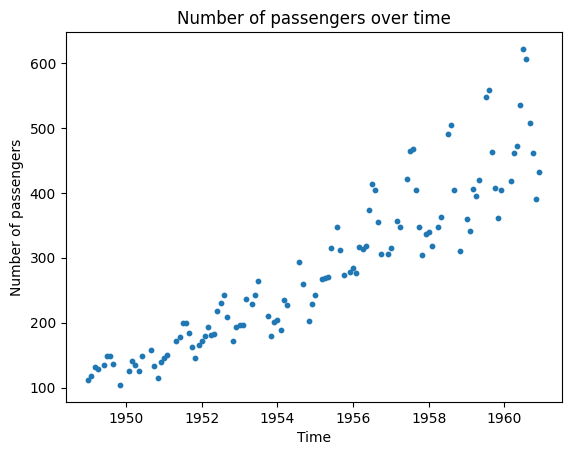

In [4]:
plt.scatter(x_train, y_train, s=10)
plt.title("Number of passengers over time")
plt.xlabel("Time")
plt.ylabel("Number of passengers")

We see that a linear function is a good candidate for regression. For this purpose, we use `LinearRegression` from the `sklearn` library.

In [5]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

Let us visualize the data and the linear regression.

Text(0, 0.5, 'Number of passengers')

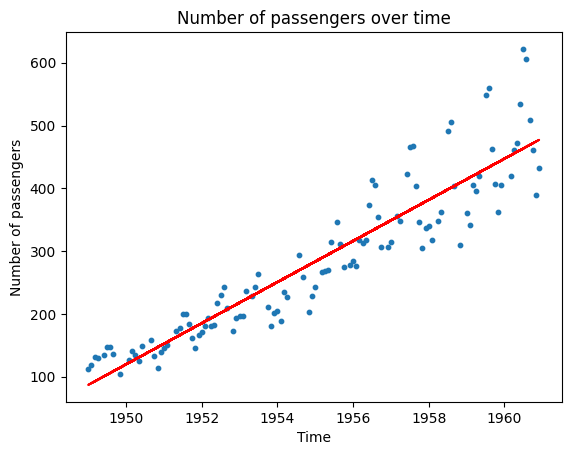

In [6]:
plt.scatter(x_train, y_train, s=10)
y_pred1 = lr.predict(x_train)
plt.plot(x_train, y_pred1, color='r')
plt.title("Number of passengers over time")
plt.xlabel("Time")
plt.ylabel("Number of passengers")

Although a linear function is a fairly good approximation of the data, we can see from the plot that a polynomial (specifically quadratic) function might be somewhat better for the data. Let us also create a polynomial model. 

In [7]:
pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)), ("model", LinearRegression())])
pipeline.fit(x_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('model', LinearRegression())])

Let us visualize this regression as well. Since `plt.plot()` requires the data for $x$ and $y$ to be in ascending order, we need to sort the data first.

Text(0, 0.5, 'Number of passengers')

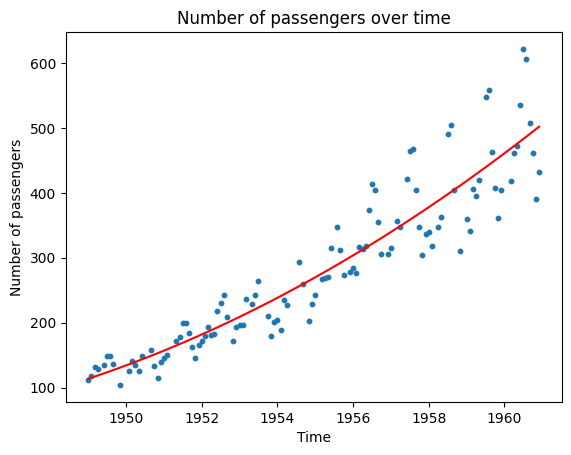

In [8]:
plt.scatter(x_train, y_train, s=10)
y_pred2 = pipeline.predict(x_train)
x_train_sorted = list(x_train["time"])
x_train_sorted.sort()
y_pred_sorted = list(y_pred2)
y_pred_sorted.sort()
plt.plot(x_train_sorted, y_pred_sorted, color='r')
plt.title("Number of passengers over time")
plt.xlabel("Time")
plt.ylabel("Number of passengers")

We see that the quadratic function fits the data somewhat better. Now we validate both models by calculating `RMSE` and `R2` for the training and test variables, and finally we perform cross-validation. We index the variables for the linear model with `1`, and those for the polynomial model with `2`.

In [9]:
RMSE1 = mean_squared_error(y_train, y_pred1, squared=False)
r21 = r2_score(y_train, y_pred1)
print(RMSE1)
print(r21)

47.31678336229581
0.8537140308232507


In [10]:
y_pred_test1 = lr.predict(x_test)
RMSEt1 = mean_squared_error(y_test, y_pred_test1, squared=False)
r2t1 = r2_score(y_test, y_pred_test1)
print(RMSEt1)
print(r2t1)

39.594633343814486
0.8422371912858828


In [11]:
scores = cross_val_score(lr, x_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
RMSEc1 = -scores.mean()
print(RMSEc1)

47.60960765147397


In [12]:
scores_2 = cross_val_score(lr, x_train, y_train, cv=3, scoring="r2")
r2c1 = scores_2.mean()
print(r2c1)

0.8467381508358716


In [13]:
RMSE2 = mean_squared_error(y_train, y_pred2, squared=False)
r22 = r2_score(y_train, y_pred2)
print(RMSE2)
print(r22)

45.76774493307632
0.8631353548621308


In [14]:
y_pred_test2 = pipeline.predict(x_test)
RMSEt2 = mean_squared_error(y_test, y_pred_test2, squared=False)
r2t2 = r2_score(y_test, y_pred_test2)
print(RMSEt2)
print(r2t2)

39.30951888059312
0.8445010592035361


In [15]:
scores = cross_val_score(pipeline, x_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
RMSEc2 = -scores.mean()
print(RMSEc2)

46.14233378519926


In [16]:
scores_2 = cross_val_score(pipeline, x_train, y_train, cv=3, scoring="r2")
r2c2 = scores_2.mean()
print(r2c2)

0.8556036425240805


Finally, let us put all the data into a `DataFrame` so that we can compare the two models more easily.

In [17]:
cmpData = [{"lin": RMSE1, "poly": RMSE2},
            {"lin": r21, "poly": r22},
            {"lin": RMSEt1, "poly": RMSEt2},
            {"lin": r2t1, "poly": r2t2},
            {"lin": RMSEc1, "poly": RMSEc2},
            {"lin": r2c1, "poly": r2c2}]
cmp = pd.DataFrame(cmpData, index=["RMSE", "R2", "RMSE Test", "R2 Test", "RMSE cross-validation", "R2 cross-validation"])
cmp

,lin,poly
RMSE,47.316783,45.767745
R2,0.853714,0.863135
RMSE Test,39.594633,39.309519
R2 Test,0.842237,0.844501
RMSE cross-validation,47.609608,46.142334
R2 cross-validation,0.846738,0.855604


We see that `R2` is quite close to $1$ in both cases, so we conclude that both models are reasonable. Also, `RMSE` is not too high. However, we do not see a large improvement in the polynomial model compared with the linear one. Finally, let us compare the plots of the models.

Text(0, 0.5, 'Number of passengers')

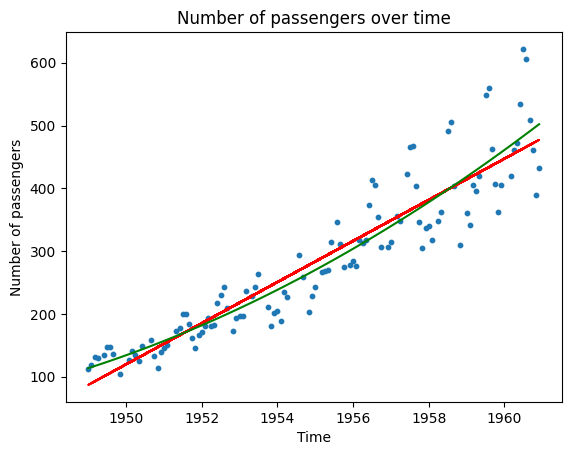

In [18]:
plt.scatter(x_train, y_train, s=10)
plt.plot(x_train, y_pred1, color='r')
plt.plot(x_train_sorted, y_pred_sorted, color='g')
plt.title("Number of passengers over time")
plt.xlabel("Time")
plt.ylabel("Number of passengers")

We see that the plots are not particularly different either. Together with the small differences in validation and the relatively small amount of data (about 150 points), it seems more likely that the linear model is more useful in this situation. Still, the quadratic model appears to provide a better description of the data in the later years, which vary considerably, so it could be more useful if we had data for the following years.

Now we will load the data for clustering. We use the `iris dataset` from the `sklearn` library. The data are about 3 different types of iris and contain the widths and lengths of their petals and sepals. We store all the data in `frame`, adding one column for the types of iris.

In [19]:
frame = sklearn.datasets.load_iris(return_X_y = True, as_frame = True)[0]
target = sklearn.datasets.load_iris(return_X_y = True, as_frame = True)[1]
frame.insert(4, "y", target)
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


First, we will visualize the data by showing the petal width and length and the sepal length on a plot. We will also color the points according to the type of iris.

Text(0.5, 0, 'Sepal length')

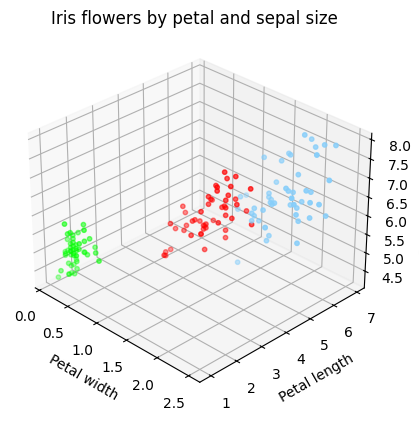

In [20]:
colors = np.array(["lime", "red", "lightskyblue"])

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.view_init(azim=-45)
ax.scatter(frame["petal width (cm)"], frame["petal length (cm)"], frame["sepal length (cm)"], s = 10, c = colors[np.array(frame["y"])])
plt.title("Iris flowers by petal and sepal size")
ax.set_xlabel("Petal width")
ax.set_ylabel("Petal length")
ax.set_zlabel("Sepal length")

We rotated the plot so that we can distinguish three groups: one, on the far left, will very clearly represent one cluster. We also see that the other two types of flower are roughly (but not perfectly) distributed into two more clusters. Therefore, we will try to determine the type of iris from these three measurements. First, we determine the number of clusters.

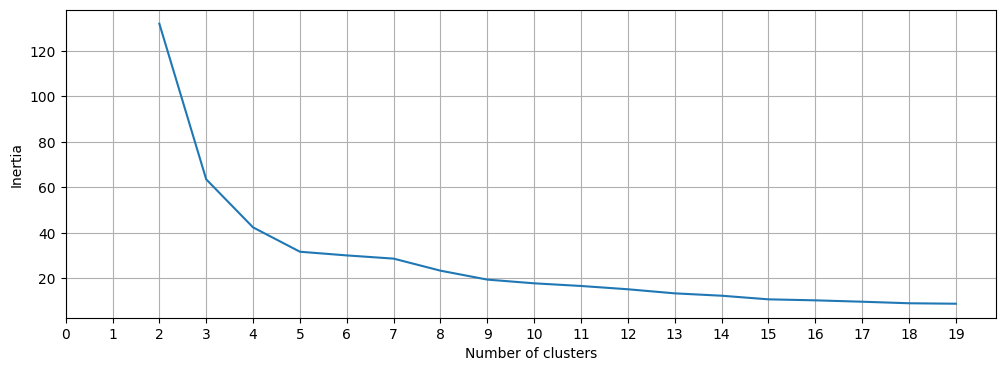

In [21]:
inercija = []

df = frame.filter(items=["petal width (cm)", "petal length (cm)", "sepal length (cm)"])

for k in range(2, 20):
    kmeans = KMeans(random_state=0, n_clusters=k)
    kmeans.fit(df)
    inercija.append(kmeans.inertia_)

plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(range(2, 20), inercija)
plt.xticks(range(0, 20))
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

The largest drop in inertia is clearly from 2 to 3 clusters, which is also expected from the previous comments. Although there is a significant drop from 3 to 4 and from 4 to 5, the drop from 2 to 3 is several times larger, and the previous plot also makes it look as though 3 clusters are the optimal number. Therefore, we will use 3. We run the *k-means* algorithm:

In [22]:
kmeans = KMeans(random_state=0, n_clusters=3)
kmeans.fit(df)
print(kmeans.cluster_centers_)

[[1.41       4.37166667 5.89666667]
 [0.246      1.462      5.006     ]
 [2.075      5.7075     6.81      ]]


We will add the clusters to the `DataFrame` containing the data for easier use.

In [23]:
frame["Cluster"] = kmeans.labels_
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


Notice that the algorithm has "swapped" the labels for the first and second types of iris. Of course, there is no reason to expect them to be the same, and this does not affect the analysis, but we will swap them anyway to make comparison with the previous visualization easier.

In [24]:
def f(x):
    if (x == 1):
        return 0
    elif (x == 0):
        return 1
    else:
        return x

frame["Cluster"] = frame["Cluster"].apply(f)
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,Cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
5,5.4,3.9,1.7,0.4,0,0
6,4.6,3.4,1.4,0.3,0,0
7,5.0,3.4,1.5,0.2,0,0
8,4.4,2.9,1.4,0.2,0,0
9,4.9,3.1,1.5,0.1,0,0


Now we can visualize the data similarly to before, except that this time we add the cluster centers and color by cluster rather than by flower type. 

Text(0.5, 0, 'Sepal length')

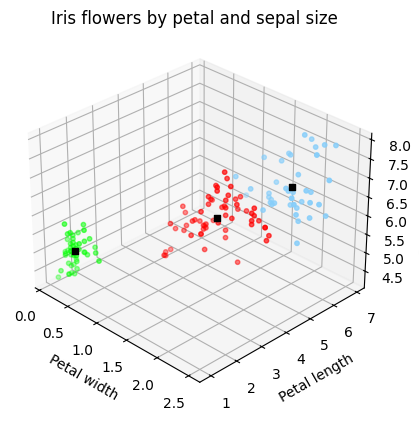

In [25]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d", computed_zorder = False)
ax.view_init(azim=-45)
for x in kmeans.cluster_centers_:
    ax.scatter(x[0], x[1], x[2], marker="s", c="black", zorder = 1)
ax.scatter(frame["petal width (cm)"], frame["petal length (cm)"], frame["sepal length (cm)"], s = 10, c = colors[np.array(frame["Cluster"])], zorder = -1)
plt.title("Iris flowers by petal and sepal size")
ax.set_xlabel("Petal width")
ax.set_ylabel("Petal length")
ax.set_zlabel("Sepal length")

We see that we have obtained a similar picture to before. For example, the green cluster on the left completely overlaps with the corresponding flower type. We expected inaccuracies between the red and blue clusters, and there are indeed some, but they mostly overlap with the corresponding types. Finally, we can check how accurately we predicted the type of iris with this algorithm:

In [26]:
corCluster = 0
totalCluster = len(frame["Cluster"]) + 1

for i in range(totalCluster - 1):
    if frame["Cluster"][i] == frame["y"][i]:
        corCluster += 1

print(corCluster/totalCluster)

0.9006622516556292


We see that the accuracy was about 90%, i.e., about 90% of all the data were assigned to the cluster corresponding to their type. Finally, we conclude that the type of an iris can be determined with a high level of certainty from the data on its petal length and width and sepal length.